In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import importlib
importlib.reload(snp)

NameError: name 'snp' is not defined

In [4]:
participants = ('P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'Mean')
expert       = (0,     1,   0,     1,   1,    0,    0)

interaction_counts = { 'Code': (3,  6, 12, 1,  14, 4,  6.7),
                       'GUI':  (12, 0, 4,  2,  4,  17, 6.5),
                       'AI':   (5,  7, 4,  11, 4,  4,  5.8)  }

interaction_time_percentages = { 'Code': (6.2,  27.6, 55.3, 0.4,  27.1, 19.6, 22.7),
                                 'GUI':  (46.7, 0.0,  18.0, 6.3,  11.0, 35.6, 19.6),
                                 'AI':   (47.1, 72.4, 26.7, 93.4, 61.9, 44.8, 57.7)  }

In [5]:
# distance to infinitely long line passing through pt1 and pt2
def distance_to_line(pt, pt1, pt2):
    
    # translate so pt1 is 0,0
    x2 = pt2[0] - pt1[0]
    y2 = pt2[1] - pt1[1]
    x  = pt[0]  - pt1[0]
    y  = pt[1]  - pt1[1]

    # find unit vector
    segment_length = (x2**2 + y2**2)**0.5

    ux2 = x2 / segment_length
    uy2 = y2 / segment_length

    # project point onto line
    distance_from_origin_on_line = x*ux2 + y*uy2

    x_proj = ux2 * distance_from_origin_on_line
    y_proj = uy2 * distance_from_origin_on_line

    # distance to projection
    return ((x-x_proj)**2 + (y-y_proj)**2)**0.5


def goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance):
    amts                 = np.array([code_amt, gui_amt, ai_amt])
    distances_rev        = np.array([no_code_distance, no_gui_distance, no_ai_distance])
    amts_ratios          = amts / sum(amts)
    distances_rev_ratios = distances_rev / sum(distances_rev)
#     print(amts_ratios)
#     print(distances_rev_ratios)
    return sum(abs(distances_rev_ratios - amts_ratios))

In [6]:
tri_xs = [-0.5, 0,        0.5, -0.5]
tri_ys = [0,    3**0.5/2, 0  , 0]

code_pt = (tri_xs[0], tri_ys[0])
gui_pt  = (tri_xs[1], tri_ys[1])
ai_pt   = (tri_xs[2], tri_ys[2])

In [7]:
def goodness2(pt, data, participant_i):
    no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
    no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
    no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

    code_amt = data['Code'][participant_i]
    gui_amt  = data['GUI'][participant_i]
    ai_amt   = data['AI'][participant_i]

    return goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)


In [8]:
import random

def find_best(data, participant_i):
    pt = 0, 0.4
    dist = 10000

    while dist > 0.0001:
        dx = (random.random() - 0.5) * 0.01
        dy = (random.random() - 0.5) * 0.01
        
        new_pt = pt[0] + dx, pt[1] + dy
        
        if goodness2(new_pt, data, participant_i) < dist:
            pt = new_pt
            dist = goodness2(pt, data, participant_i)
#             print(dist)

#     print(participant_i, dist, pt)
    return pt

In [9]:
interaction_time_xs = []
interaction_time_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_time_percentages, participant_i)
    interaction_time_xs.append(x)
    interaction_time_ys.append(y)

print(interaction_time_xs)
print(interaction_time_ys)

interaction_counts_xs = []
interaction_counts_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_counts, participant_i)
    interaction_counts_xs.append(x)
    interaction_counts_ys.append(y)

print(interaction_counts_xs)
print(interaction_counts_ys)

[0.20452039724365573, 0.22403649631649328, -0.14303198995571922, 0.46452323993279826, 0.17402780904751058, 0.1259607507883488, 0.1750023755207598]
[0.4044628279167994, 5.506072441182553e-06, 0.15588938065984154, 0.05447669231831865, 0.09526997447066653, 0.3083079747727566, 0.16973886589355563]
[0.05002602879299896, 0.0384366152649804, -0.2000254390724662, 0.3571032894540571, -0.22725966087017724, -2.1712547719924247e-05, -0.023693756023457607]
[0.5196008127413465, 1.963056560241084e-05, 0.17324585928421768, 0.12370534263596018, 0.15747511017633095, 0.5889205481195775, 0.29624984028769946]


In [10]:
import IPython
import time

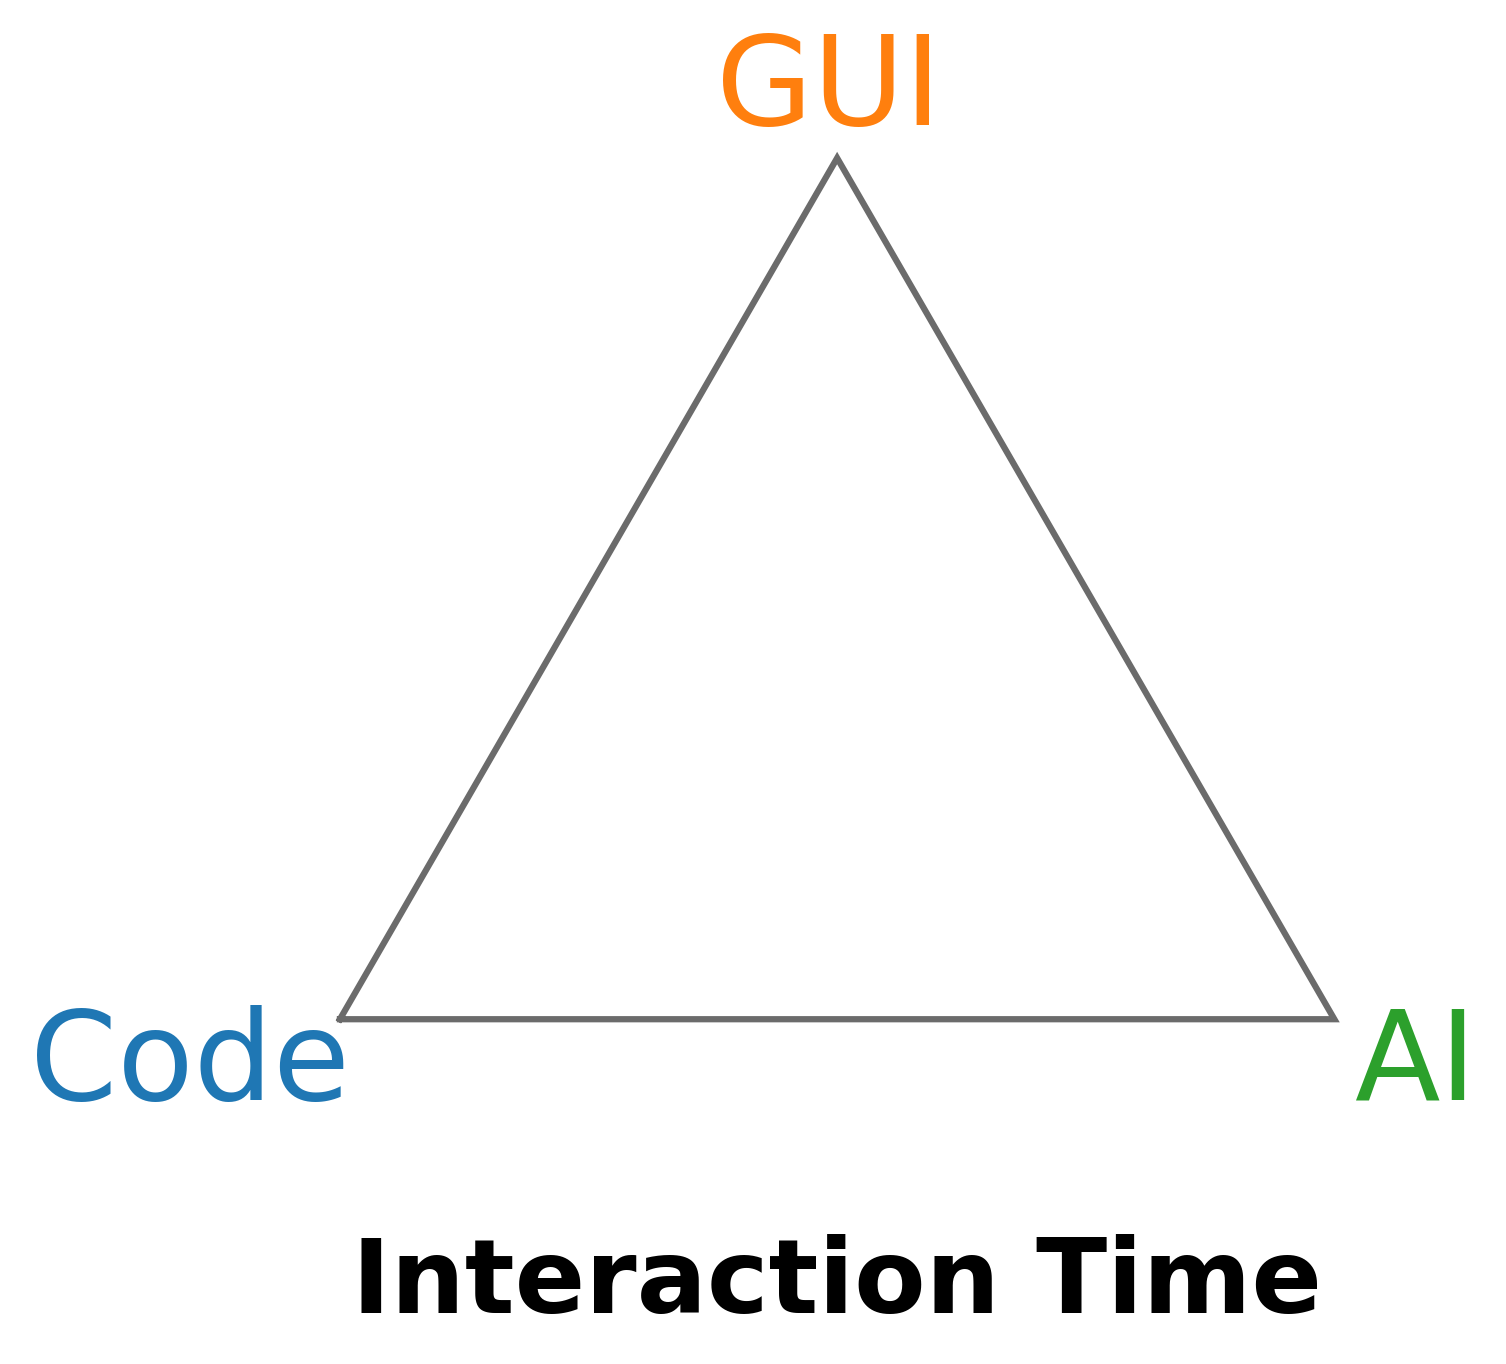

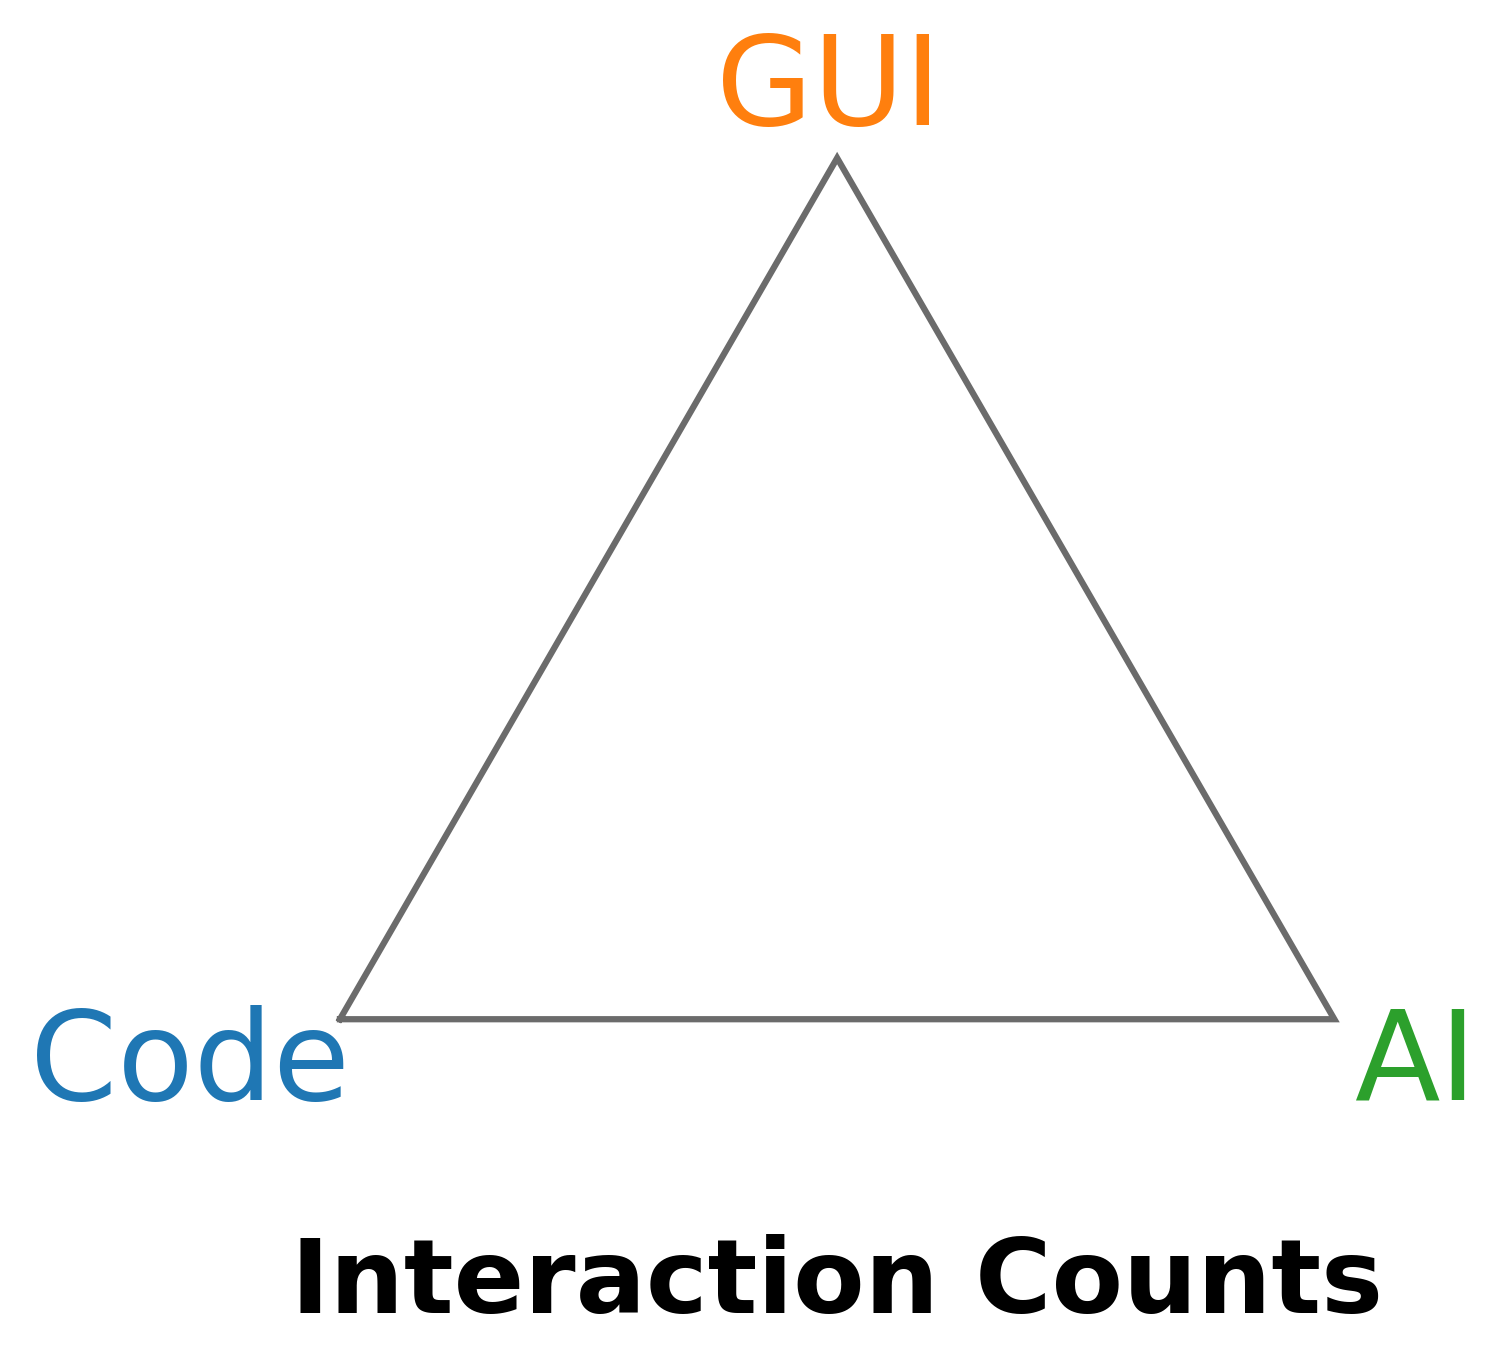

In [20]:
time0 = time.time()

# Didn't look up anything in the docs
#
# Lots of on-plot manipulation, although many values were later set manually in the properties panel
# to get more exact locations.
#
# Used AI to get the x and y scales to be locked proportionally 1-to-1
# after searching the add_subplot properties and failing to find the right option

def tri_plot(title, xs, ys):
    fig = plt.figure(layout='tight', dpi=300, facecolor=(1,1,1,0))
    ax = fig.add_subplot(1, 1, 1)

    # extracted this manually, of course
    border_color = (0.42, 0.42, 0.42)

    # didn't have to look up the joinstyle docs to get the sharp corners, I would have guessed "sharp"
    ax.plot(tri_xs, tri_ys, color=border_color, solid_joinstyle='miter')

    # Used AI for this line
    ax.set_aspect('equal', adjustable='box')

    # Learned this line from using AI for the overview example
    # entered manually here after AI gave too many lines of code for the same thing
    ax.axis('off')

    # was nice to be able to try out properties to e.g. toggle on rotation_mode
#     text9 = ax.text(0.246, 3**0.5/4, 'No Code', color=border_color, horizontalalignment='center', rotation=-60, verticalalignment='bottom', rotation_mode='anchor', fontsize='large')
#     text11 = ax.text(-0.246, 3**0.5/4, 'No AI', color=border_color, horizontalalignment='center', rotation=60, verticalalignment='bottom', rotation_mode='anchor', fontsize='large')
#     text12 = ax.text(0, -0.005, 'No GUI', color=border_color, horizontalalignment='center', verticalalignment='top', fontsize='large')

    for i, name in enumerate(participants):
        pass
        # was able to find horizontalalignment='center' and verticalalignment='center' in the properties panel
#         text3 = ax.text(xs[i], ys[i], name, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=16)

    # Would be really nice to link properites, e.g. fontsize here (Sketch-n-Sketch Make Equal)
    text4 = ax.text(-0.009, 0.9, 'GUI', fontsize=30, horizontalalignment='center', color='C1')
    text5 = ax.text(-0.49, -0.08, 'Code', fontsize=30, horizontalalignment='right', color='C0')

    # Poor man's alignment: used slider for x after duplicating the above line
    text6 = ax.text(0.52, -0.08, 'AI', fontsize=30, horizontalalignment='left', color='C2')

    text8 = ax.set_title(title, y=-0.29, fontsize=25, fontweight='demi')

#     IPython.display.display(fig)
    plt.show()

tri_plot('Interaction Time', interaction_time_xs, interaction_time_ys)
out = tri_plot('Interaction Counts', interaction_counts_xs, interaction_counts_ys)

dur = time.time() - time0
# print(f"cell: {dur:.2f} seconds")

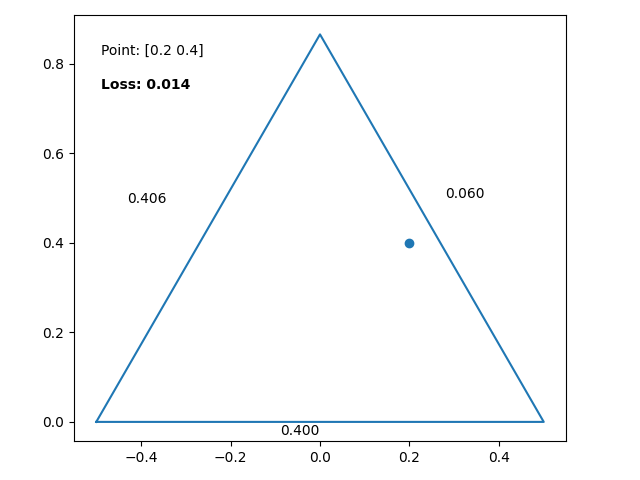

In [11]:
# keep this version around for historical purposes

fig = plt.figure(layout='tight', dpi=300)
ax = fig.add_subplot(1, 1, 1)

ax.plot(tri_xs, tri_ys)

# had to ask the AI for this line
ax.set_aspect('equal', adjustable='box')

# paths = ax.scatter(0.205, 0.405)
paths = ax.scatter(0.2, 0.4)

participant_i = 0

pt = paths.get_offsets()[participant_i]

no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

text = ax.text(-0.49, 0.82,  f'Point: {pt}')
text = ax.text(-0.09, -0.03, f'{no_gui_distance:.3f}')
text = ax.text(-0.38, 0.49, f'{no_ai_distance:.3f}')
text = ax.text(0.28, 0.5,    f'{no_code_distance:.3f}')

code_amt = interaction_time_percentages['Code'][participant_i]
gui_amt  = interaction_time_percentages['GUI'][participant_i]
ai_amt   = interaction_time_percentages['AI'][participant_i]

dist = goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)

text2 = ax.text(-0.49, 0.745, f'Loss: {dist:.3f}', fontweight='bold')

plt.show()